##  House Price prediction - EDA 

- Exploring housing dataset and find strongest predictors for SalesPrice 


In [1]:
# all required libs for importing and ploting data  
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import dabl as dbl

In [2]:
#quick load data and check top 5 samples in data 
data= pd.read_csv("train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Overview
- Quick loockup on the data shape and size and colums for data understanding.
- statistical discription of target (mean,minimum,maximum etc..)

In [3]:
data.shape

(1460, 81)

In [4]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
data["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Target Distribution 
- "SalesPrice" distribution matter before going furthur 


<Axes: xlabel='SalePrice', ylabel='Count'>

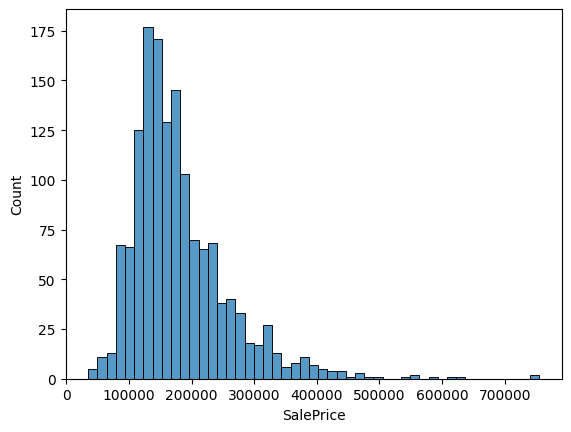

In [6]:
# ploting distribution to see shape 
sns.histplot(data["SalePrice"])

## Auto EDA using dabl lib
- it uses all 81 features and gives a type ,distribytion,target relationship and plotting of features with respective target

In [7]:
#Returns whole details of data induvidually 
dbl.detect_types(data).T

C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed indivi

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
continuous,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
dirty_float,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
low_card_int_ordinal,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
low_card_int_categorical,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
categorical,False,False,True,False,False,False,True,True,True,False,...,False,False,True,True,False,False,True,True,True,False
date,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
free_string,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
useless,True,False,False,False,False,True,False,False,False,True,...,True,True,False,False,True,False,False,False,False,False


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed indivi

Target looks like regression


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\utils.py:712: UserWarning: Dropped 2 outliers in column SalePrice.
  warn("Dropped {} outliers in column {}.".format(
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:652: UserWarning: Discarding 2 outliers in target column.
  warn(f"Discarding {n_outliers} outliers in target column.",
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:111: UserWarning: Showing only top 10 continuous features.
  warn("Showing only top 10 continuous features.")


Showing only top 10 of 44 categorical features


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0

[<Axes: title={'center': 'Target distribution'}, xlabel='SalePrice', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=8.09E-01'}, xlabel='OverallQual (jittered)', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=7.30E-01'}, xlabel='GrLivArea'>,
         <Axes: title={'center': 'F=6.53E-01'}, xlabel='YearBuilt'>,
         <Axes: title={'center': 'F=6.48E-01'}, xlabel='GarageArea'>,
         <Axes: title={'center': 'F=6.01E-01'}, xlabel='TotalBsmtSF'>],
        [<Axes: title={'center': 'F=5.94E-01'}, xlabel='GarageYrBlt', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=5.74E-01'}, xlabel='1stFlrSF'>,
         <Axes: title={'center': 'F=5.72E-01'}, xlabel='YearRemodAdd'>,
         <Axes: title={'center': 'F=5.31E-01'}, xlabel='TotRmsAbvGrd (jittered)'>,
         <Axes: title={'center': 'F=4.77E-01'}, xlabel='OpenPorchSF'>]],
       dtype=object),
 array([[<Axes: title={'center': 'F=5.27E-01'}, xlabel='SalePrice', ylabel='MSSubClass'>,
         <Axes: title={'cente

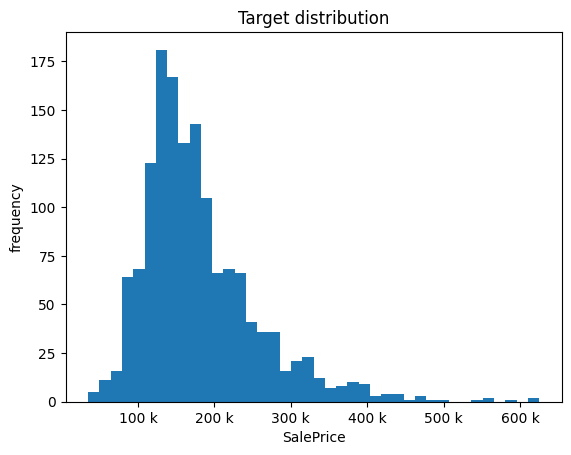

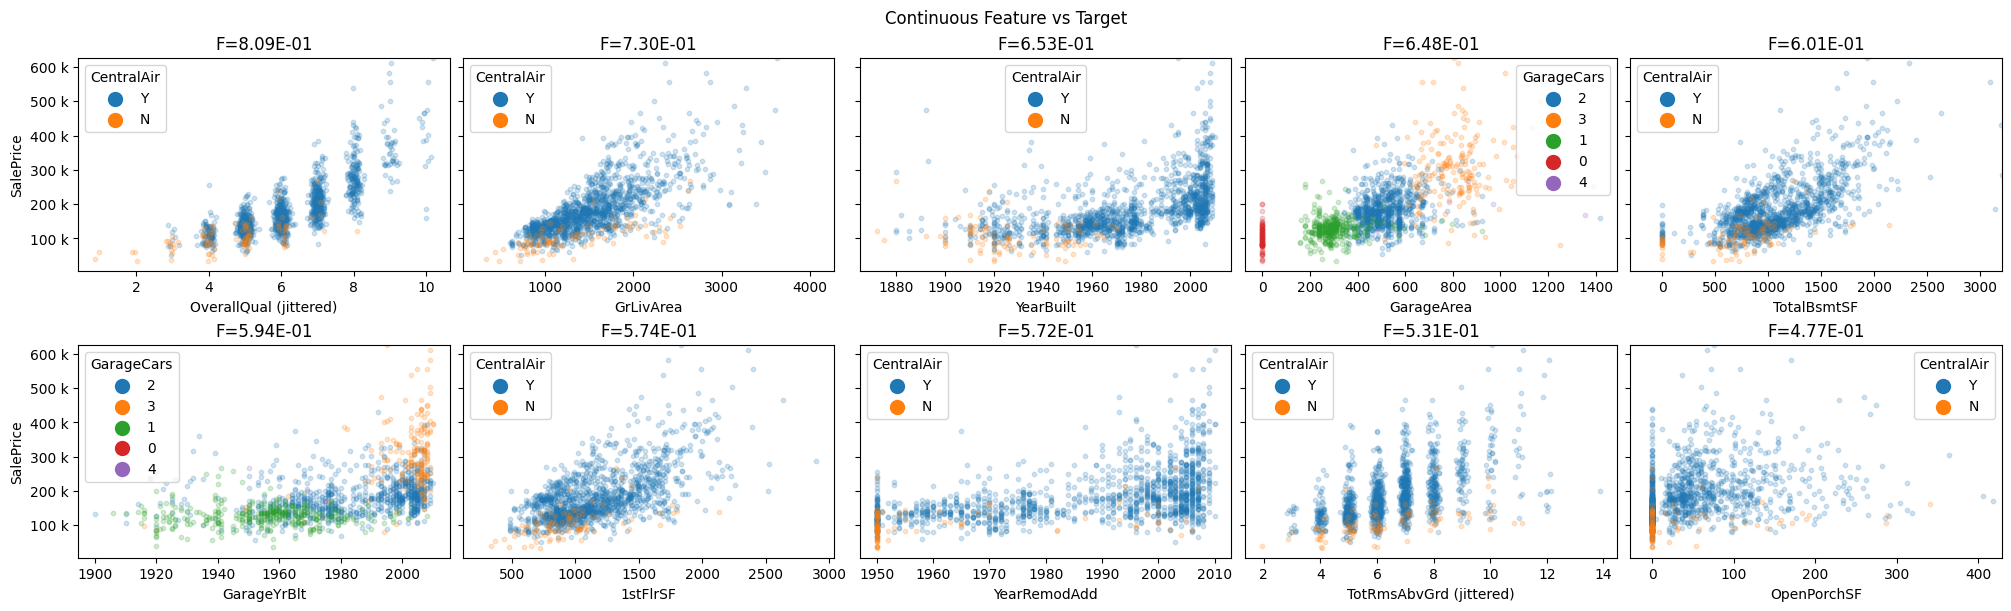

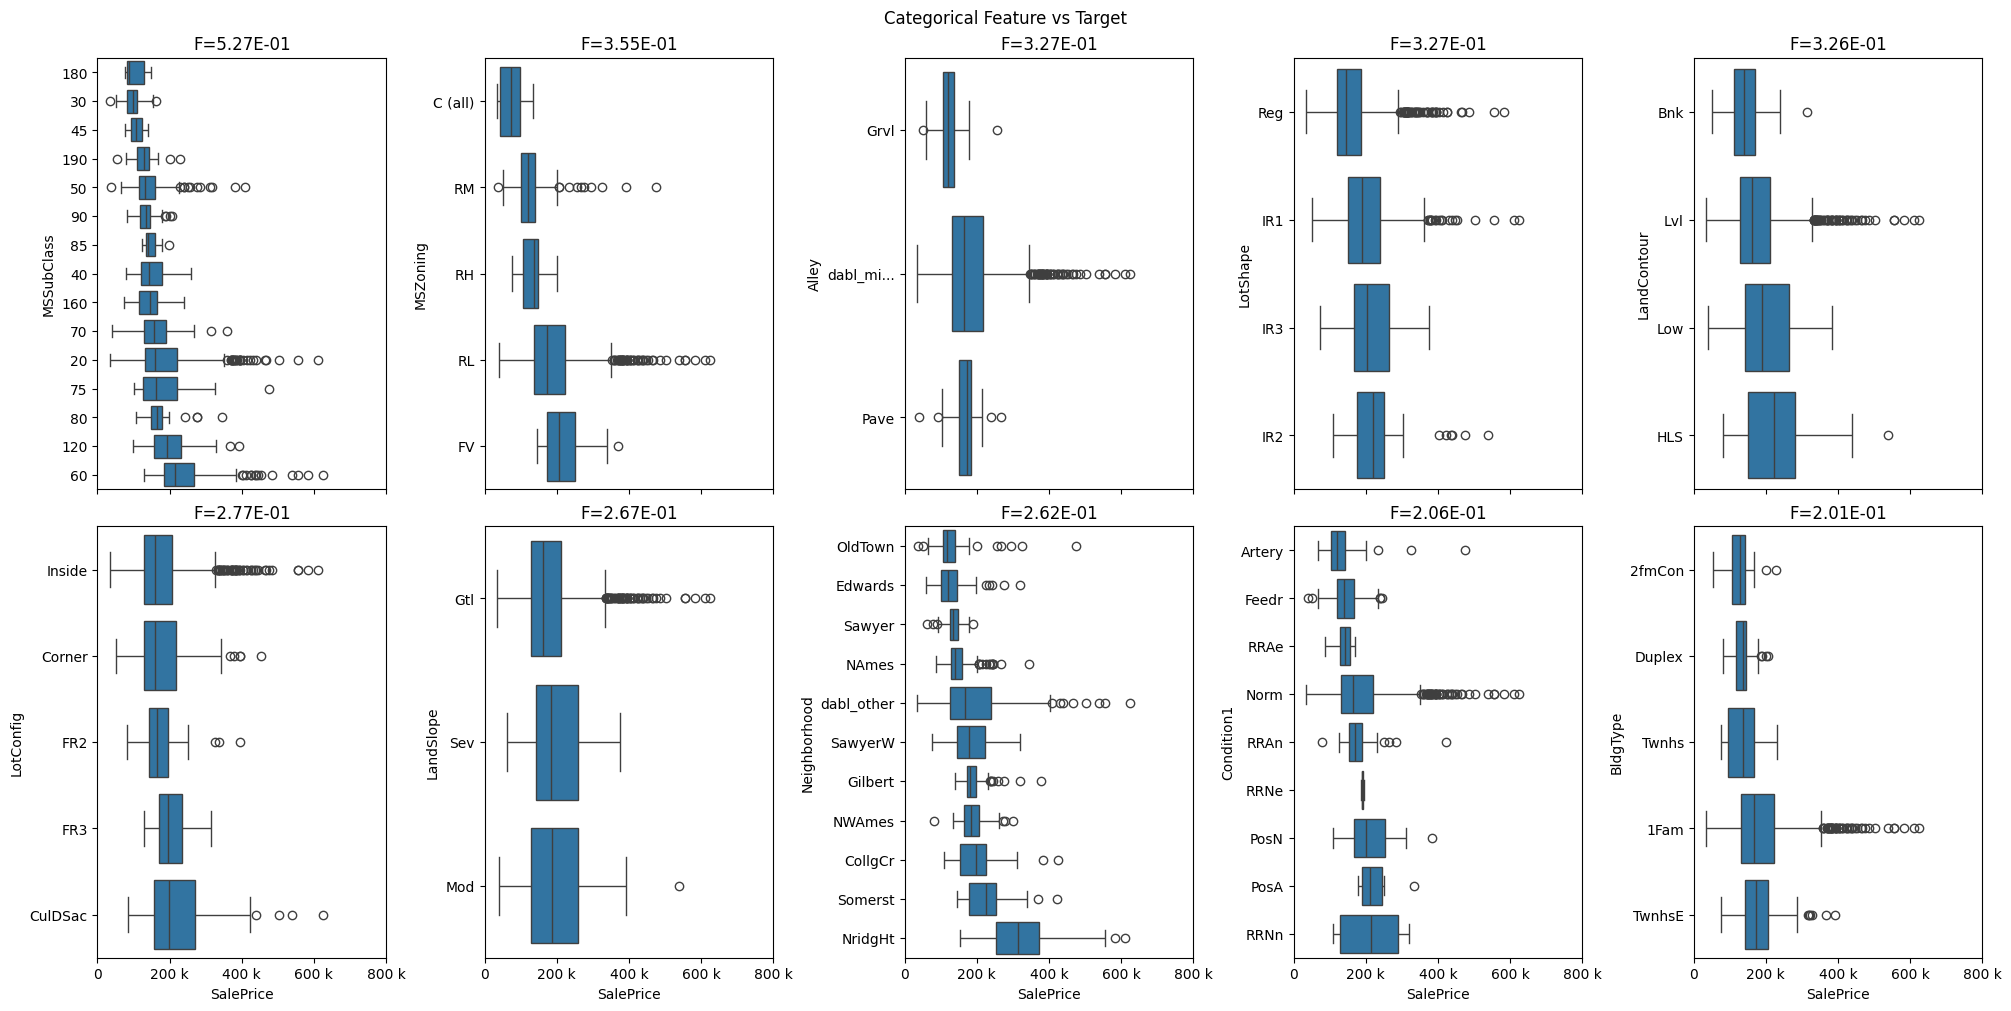

In [8]:
#Gives all plots of data which can be plot using SalesPrice as a target 
# no need to specify type of plots 
dbl.plot(data,target_col="SalePrice")

## Correlation Analysis

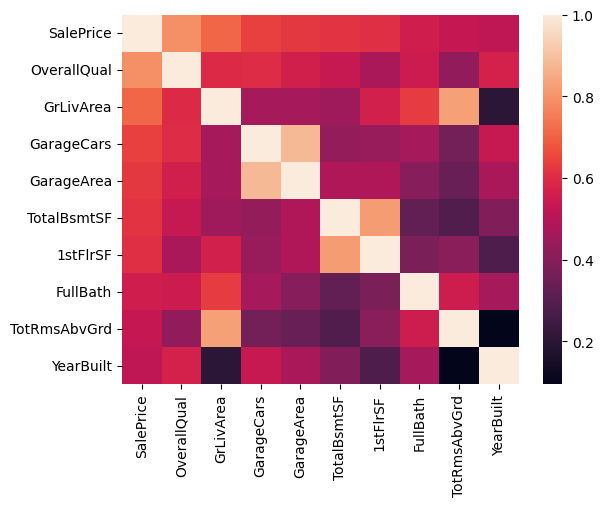

In [9]:
# Correlation Heatmap of top k=10 featurs in the dataset  
numeric_df = data.select_dtypes(include='number')
cor=numeric_df.corr()
k=10
co=cor.nlargest(k,"SalePrice")["SalePrice"].index
cm=np.corrcoef(data[co].values.T)
heat=sns.heatmap(cm,yticklabels=co.values,xticklabels=co.values)
plt.show()


In [10]:
cols=[co.values]
cols

[array(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
        'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath',
        'TotRmsAbvGrd', 'YearBuilt'], dtype=object)]

Target looks like regression


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\utils.py:712: UserWarning: Dropped 2 outliers in column SalePrice.
  warn("Dropped {} outliers in column {}.".format(
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:652: UserWarning: Discarding 2 outliers in target column.
  warn(f"Discarding {n_outliers} outliers in target column.",
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].med

[<Axes: title={'center': 'Target distribution'}, xlabel='SalePrice', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=8.09E-01'}, xlabel='OverallQual (jittered)', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=7.30E-01'}, xlabel='GrLivArea'>,
         <Axes: title={'center': 'F=6.53E-01'}, xlabel='YearBuilt'>,
         <Axes: title={'center': 'F=6.48E-01'}, xlabel='GarageArea'>],
        [<Axes: title={'center': 'F=6.01E-01'}, xlabel='TotalBsmtSF', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=5.74E-01'}, xlabel='1stFlrSF'>,
         <Axes: title={'center': 'F=5.31E-01'}, xlabel='TotRmsAbvGrd (jittered)'>,
         <Axes: >]], dtype=object),
 array([[<Axes: title={'center': 'F=3.58E-01'}, xlabel='SalePrice', ylabel='GarageCars'>,
         <Axes: title={'center': 'F=2.57E-01'}, xlabel='SalePrice', ylabel='FullBath'>]],
       dtype=object)]

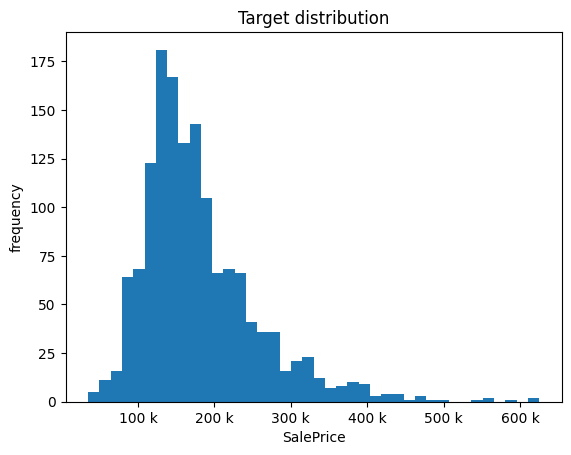

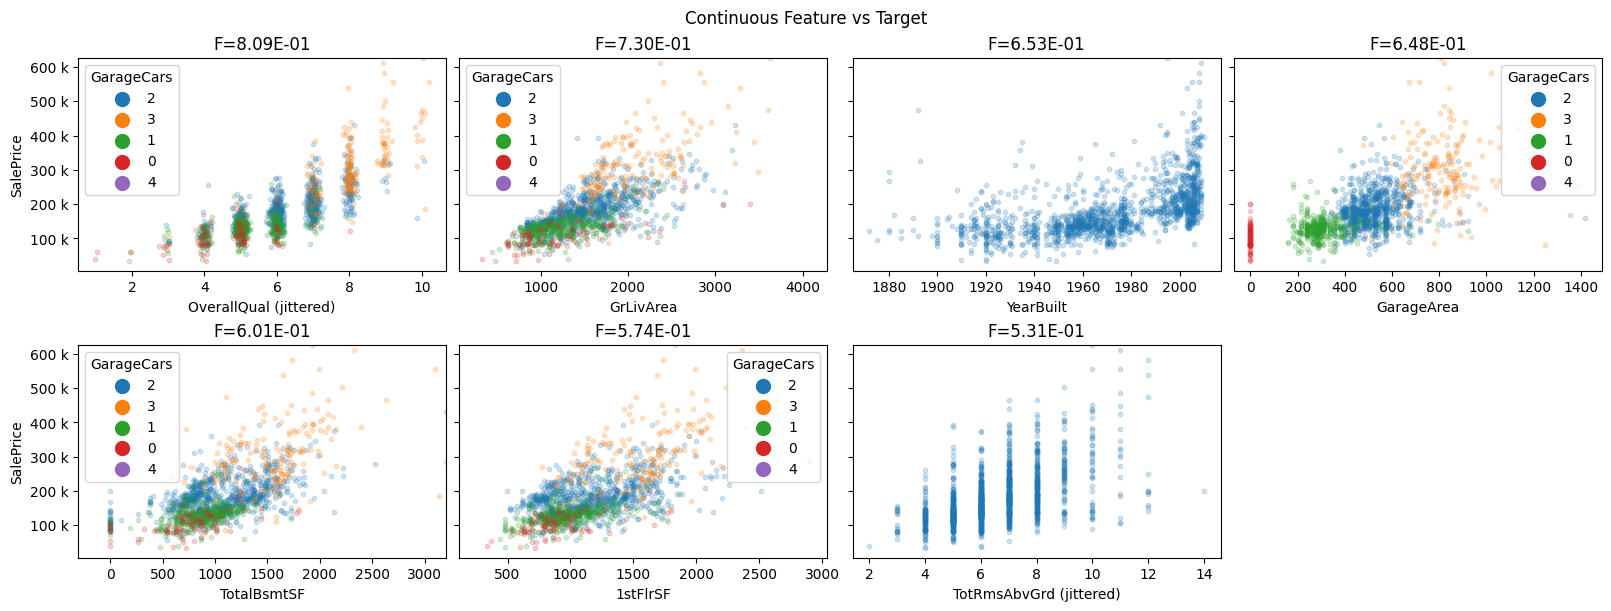

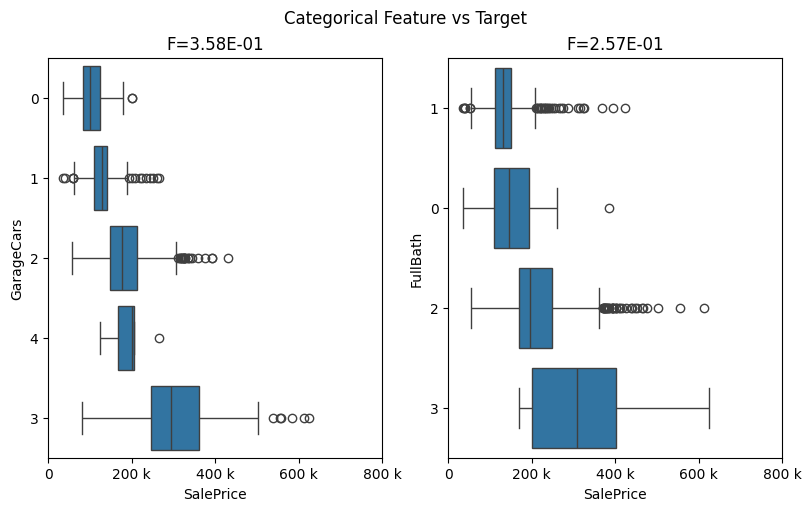

In [11]:
# Ploting the final 10 elements according to target to find out outliers and any other details in featurs 
dbl.plot(data[co],target_col="SalePrice")

In [12]:
df=data[co]

In [13]:
df

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt
0,208500,7,1710,2,548,856,856,2,8,2003
1,181500,6,1262,2,460,1262,1262,2,6,1976
2,223500,7,1786,2,608,920,920,2,6,2001
3,140000,7,1717,3,642,756,961,1,7,1915
4,250000,8,2198,3,836,1145,1145,2,9,2000
...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,460,953,953,2,7,1999
1456,210000,6,2073,2,500,1542,2073,2,7,1978
1457,266500,7,2340,1,252,1152,1188,2,9,1941
1458,142125,5,1078,1,240,1078,1078,1,5,1950


## Data Quality Check 

In [14]:
df.isnull().sum()

SalePrice       0
OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalePrice     1460 non-null   int64
 1   OverallQual   1460 non-null   int64
 2   GrLivArea     1460 non-null   int64
 3   GarageCars    1460 non-null   int64
 4   GarageArea    1460 non-null   int64
 5   TotalBsmtSF   1460 non-null   int64
 6   1stFlrSF      1460 non-null   int64
 7   FullBath      1460 non-null   int64
 8   TotRmsAbvGrd  1460 non-null   int64
 9   YearBuilt     1460 non-null   int64
dtypes: int64(10)
memory usage: 114.2 KB


## Prep for Model training 

In [17]:
#separating data to train and test using model 
x = df.drop(columns="SalePrice")
y=df["SalePrice"]

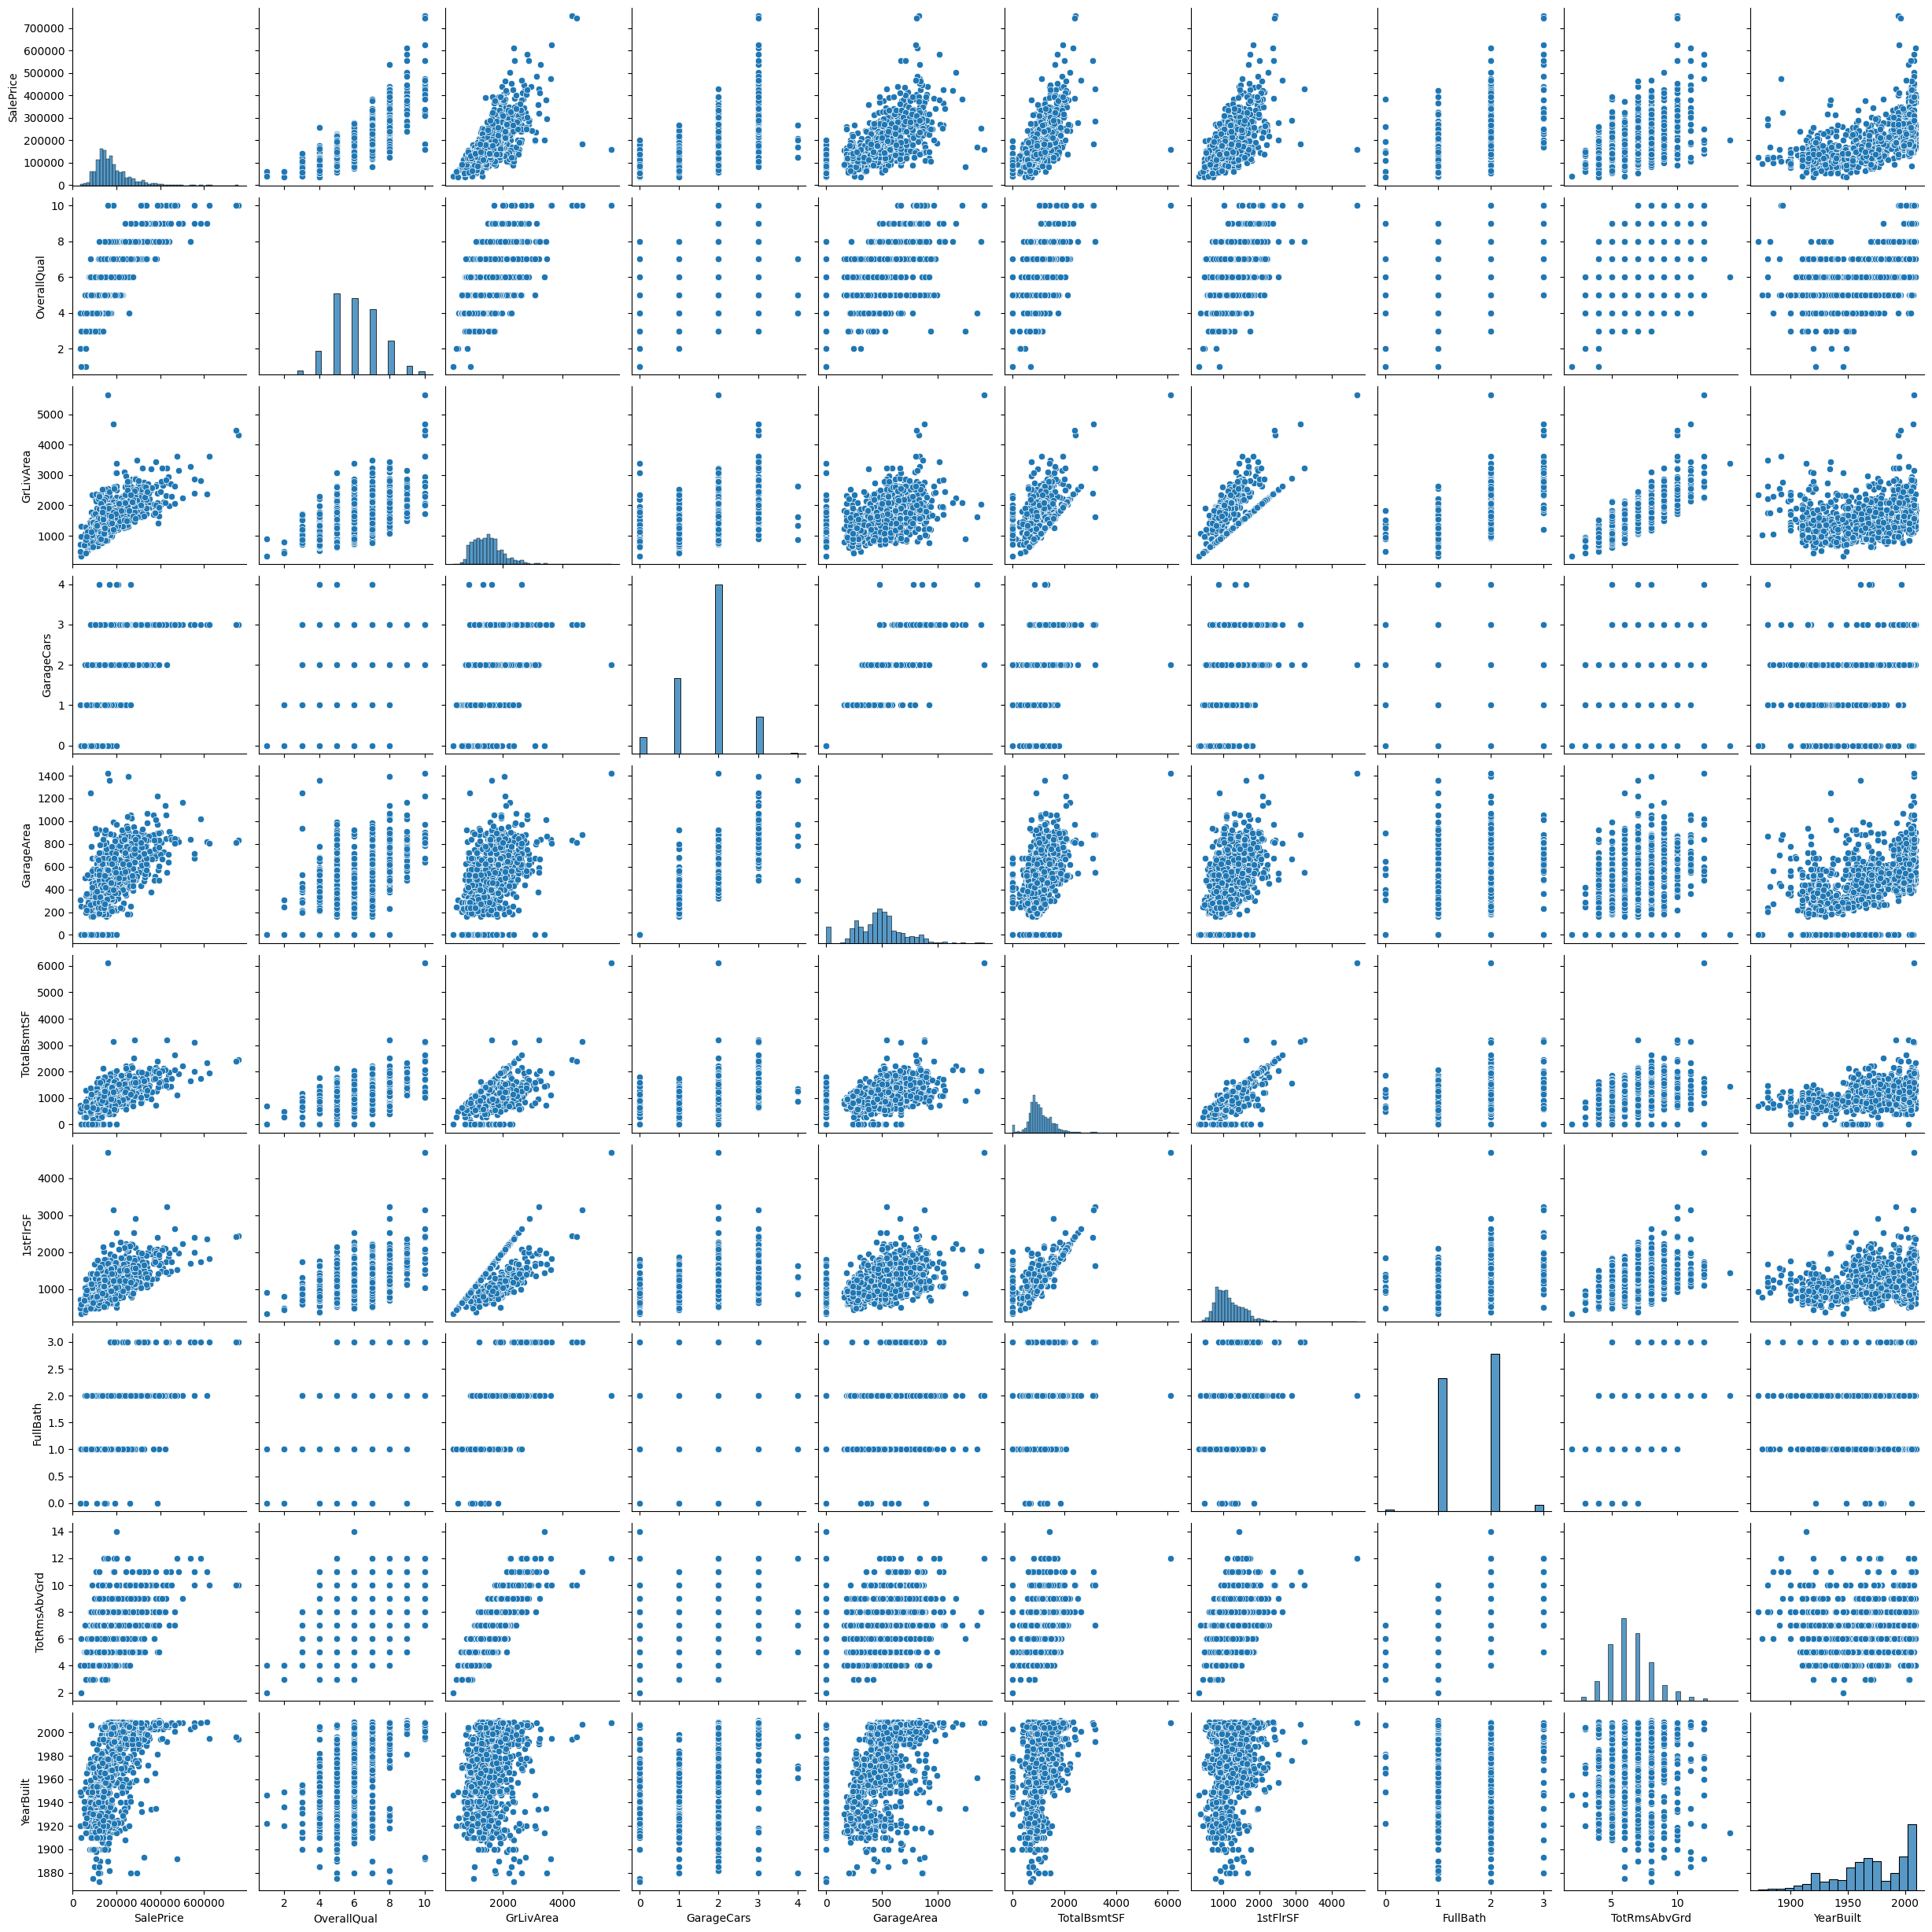

In [18]:
sns.pairplot(df)
plt.show()

In [19]:
df["SalePrice"]=np.log(df["SalePrice"])

C:\Users\Nihal\AppData\Local\Temp\ipykernel_15624\2758011382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SalePrice"]=np.log(df["SalePrice"])


In [20]:
from scipy import stats
from scipy.stats import norm

C:\Users\Nihal\AppData\Local\Temp\ipykernel_15624\3650667639.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["SalePrice"],fit=norm)


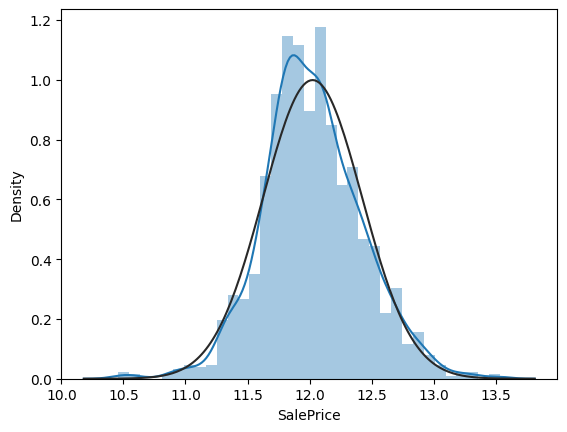

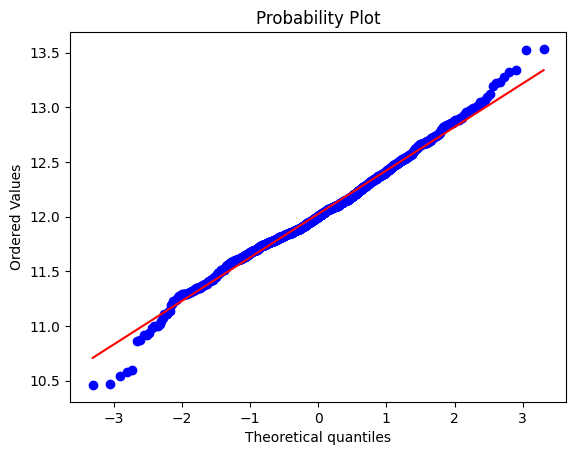

In [21]:
sns.distplot(df["SalePrice"],fit=norm)
fig=plt.figure()
res=stats.probplot(df["SalePrice"],plot=plt)

In [22]:
x1=df.drop(columns="SalePrice")
y1=df["SalePrice"]

In [23]:
from scipy.stats import skew
numeric=df.select_dtypes(include=np.number).columns
skewness=df[numeric].apply(lambda s: skew(s.dropna()))
skw=skewness[abs(skewness)>0.75].index
print(f"logging{len(skw)} skewed features")


logging3 skewed features


In [24]:
df[skw]=np.log1p(df[skw])

C:\Users\Nihal\AppData\Local\Temp\ipykernel_15624\951792892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[skw]=np.log1p(df[skw])


In [25]:
x2=df.drop(columns="SalePrice")
y2=df["SalePrice"]

In [27]:
!pip install xgboost lightgbm catboost


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Nihal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


x_train, x_test, y_train, y_test = train_test_split(x2, y2, test_size=0.3, random_state=54)

models = {
    " DecisionTree":      DecisionTreeRegressor(max_depth=3,random_state=42),
    "RandomForest":      RandomForestRegressor(n_estimators=100,random_state=42),
    "AdaBoost":      AdaBoostRegressor(n_estimators=200,random_state=42),
    "CatBoost": CatBoostRegressor(n_estimators=300,learning_rate=0.05,max_depth=3,random_state=42),
    "Gradientboost":GradientBoostingRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42),
    "xgb": XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,random_state=42),
    "LightBoost":LGBMRegressor(learning_rate=0.05,max_depth=3,random_state=42)
}

scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale  = scaler.transform(x_test)

# --- CV setup ---
kf = KFold(n_splits=5, shuffle=True, random_state=54)

performance_data = []
for name, model in models.items():
    # fit on train split
    model.fit(x_train, y_train)
    train_pred = model.predict(x_train)
    test_pred  = model.predict(x_test)

    # single-split metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))
    r2_train   = r2_score(y_train, train_pred)
    r2_test    = r2_score(y_test,  test_pred)

    # CV metrics on TRAIN only (no test leak)
    cv_rmse = -cross_val_score(model, x_train, y_train, cv=kf,
                                scoring='neg_root_mean_squared_error')
    cv_r2   =  cross_val_score(model, x_train, y_train, cv=kf, scoring='r2')

    performance_data.append({
        "model":        name,
        "train RMSE":   round(train_rmse, 4),
        "test RMSE":    round(test_rmse, 4),
        "r2 train":     round(r2_train, 4),
        "r2 test":      round(r2_test, 4),
        "CV RMSE mean": round(cv_rmse.mean(), 4),
        "CV RMSE std":  round(cv_rmse.std(), 4),
        "CV R2 mean":   round(cv_r2.mean(), 4),
        "CV R2 std":    round(cv_r2.std(), 4),
    })

result = pd.DataFrame(performance_data).sort_values("CV RMSE mean").reset_index(drop=True)
print("=== Model Performance (sorted by CV RMSE) ===")
display(result)    


0:	learn: 0.3909672	total: 806us	remaining: 241ms
1:	learn: 0.3805748	total: 1.78ms	remaining: 266ms
2:	learn: 0.3700244	total: 2.64ms	remaining: 261ms
3:	learn: 0.3597185	total: 3.56ms	remaining: 263ms
4:	learn: 0.3503377	total: 4.49ms	remaining: 265ms
5:	learn: 0.3410947	total: 6.04ms	remaining: 296ms
6:	learn: 0.3323664	total: 7.08ms	remaining: 296ms
7:	learn: 0.3241248	total: 7.98ms	remaining: 291ms
8:	learn: 0.3170172	total: 8.74ms	remaining: 283ms
9:	learn: 0.3098314	total: 9.56ms	remaining: 277ms
10:	learn: 0.3027611	total: 10.3ms	remaining: 271ms
11:	learn: 0.2955832	total: 11ms	remaining: 265ms
12:	learn: 0.2895169	total: 11.8ms	remaining: 261ms
13:	learn: 0.2832565	total: 12.6ms	remaining: 257ms
14:	learn: 0.2772151	total: 13.4ms	remaining: 254ms
15:	learn: 0.2716471	total: 14.1ms	remaining: 251ms
16:	learn: 0.2662983	total: 15.1ms	remaining: 251ms
17:	learn: 0.2615446	total: 16.2ms	remaining: 254ms
18:	learn: 0.2572371	total: 17.1ms	remaining: 253ms
19:	learn: 0.2526077	tota

,model,train RMSE,test RMSE,r2 train,r2 test,CV RMSE mean,CV RMSE std,CV R2 mean,CV R2 std
0,CatBoost,0.1395,0.1507,0.8803,0.8502,0.1644,0.0126,0.8327,0.0237
1,LightBoost,0.1411,0.1580,0.8776,0.8353,0.1658,0.0098,0.8302,0.0171
2,Gradientboost,0.1175,0.1507,0.9152,0.8503,0.1688,0.0128,0.8231,0.0286
3,RandomForest,0.0638,0.1526,0.9749,0.8464,0.1722,0.0140,0.8157,0.0314
4,xgb,0.0462,0.1578,0.9869,0.8358,0.1786,0.0098,0.8024,0.0225
5,AdaBoost,0.1857,0.2022,0.7881,0.7303,0.2103,0.0073,0.7262,0.0262
6,DecisionTree,0.2161,0.2155,0.7129,0.6937,0.2279,0.0096,0.6782,0.0356
